### Retrival-Augmented Generation (RAG)


- Prompting: 提供给模型的文本输入即为prompt，基于该输入，LLM生成相应。通过精炼的输入来引导模型的输出
- RAG：将prompt与外部数据进行关联，基于该关联，LLM生成相应
- Fine-tuning: 使用特定于任务的数据调整LLM的参数，以使其在某个领域更为专业化。可以在特定领域上对语言模型进行Fine-tuning，使其更擅长回答基于此领域的问题

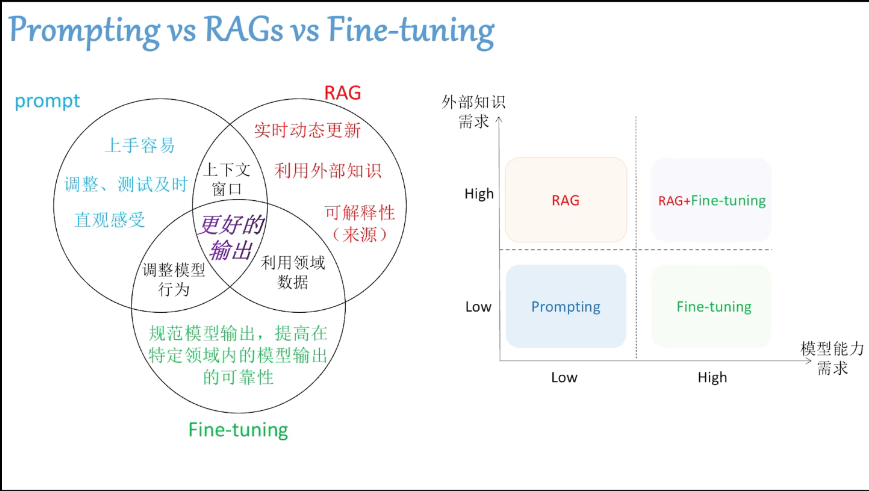

#### 快速实现RAG-LLM

- 流程：query -> embedding -> 问题查询 -> vectorab -> 相关上下文 -> Augmented -> LLM -> 生成回答

- 核心阶段：
  - 索引：将外部文档转化为一种容易被查找的格式
  - 检索：当用户提出问题时，系统会根据问题从索引中找出最相关的文档片段
  - 生成：将检索到的“参考资料”和用户的问题一起给LLM，让其生成一个有理有据的问答

In [11]:
import os 
import bs4
DASHSCOPE_API_KEY = "sk-bb5a3bc665be4d35bea3efce0196c8c1"
os.environ["DASHSCOPE_API_KEY"] = DASHSCOPE_API_KEY
from langchain_classic import hub
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_text_splitters import CharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.chat_models.tongyi import ChatTongyi
WEB_URL = "https://lilianweng.github.io/posts/2023-06-23-agent/"  # 目标网页
CHUNK_SIZE = 1000  # 文本分块大小
CHUNK_OVERLAP = 200  # 分块重叠长度
EMBEDDING_MODEL = "all-MiniLM-L6-v2"  # 免费嵌入模型
LLM_MODEL = "qwen-turbo"  # 通义千问免费模型
TEMPERATURE = 0.0  # 生成温度（0=稳定输出）

### Overview

In [12]:
# Indexing 
loader = WebBaseLoader(
    web_paths=(WEB_URL,),
    bs_kwargs={
        "parse_only": bs4.SoupStrainer(class_=("post-content", "post-title", "post-header"))
    }
)
docs = loader.load()
print(docs[0])

page_content='

      LLM Powered Autonomous Agents
    
Date: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng


Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.
Agent System Overview#
In a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:

Planning

Subgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.
Reflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final results.


Memory

Short-t

In [13]:
# split
text_splitter = CharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    separator="\n",  # 按换行符分割，更符合文本逻辑
    length_function=len  # 按字符数计算长度
)
splits = text_splitter.split_documents(docs)
print(f"Total splits: {len(splits)}")
print(splits[0].page_content[:200])  # 打印第一个分块

Created a chunk of size 2082, which is longer than the specified 1000
Created a chunk of size 1172, which is longer than the specified 1000


Total splits: 53
LLM Powered Autonomous Agents
    
Date: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng
Building agents with LLM (large language model) as its core controller is a cool conce


In [14]:
# Embed
embeddings = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL,
    model_kwargs={"device": "cpu"},  # 仅用CPU，无需GPU
    encode_kwargs={"normalize_embeddings": True}  # 归一化向量，提升检索精度
)
vectorstore = Chroma.from_documents(
    documents=splits,
    embedding=embeddings,
    persist_directory="./chroma_db"  # 向量库保存路径
)
vectorstore.persist()  # 持久化存储
retriever = vectorstore.as_retriever(search_kwargs={"k": 3}) 

C:\Users\23017\AppData\Local\Temp\ipykernel_24776\2581447423.py:2: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1133.55it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [15]:
#prompt
prompt = hub.pull("rlm/rag-prompt")
llm = ChatTongyi(
    model=LLM_MODEL,
    temperature=TEMPERATURE,
    dashscope_api_key=DASHSCOPE_API_KEY
)

def format_docs(docs):
    return "\n\n".join([f"Document {i+1}:\n{doc.page_content}" for i, doc in enumerate(docs)])

rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

In [19]:
#Generation
question = "请用中文回答：这份文档大概的工作是？"
result = rag_chain.invoke(question)

print(result)

这份文档的工作是指导如何正确创建和组织代码文件，确保代码功能完整、结构合理，并遵循最佳实践。它要求按照入口文件依次处理导入的文件，保持不同文件间的兼容性。同时，需要包含所有必要的依赖定义和文件命名规范。


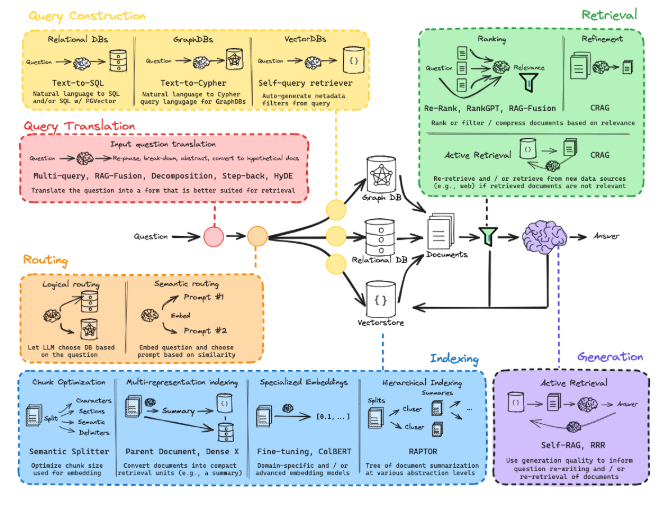